# 01 Data Inspection and Preprocessing

This notebook loads the raw radar windows, inspects the data, builds temporal samples, normalizes them with train statistics, and saves the processed arrays used by the next notebooks.


In [173]:
!pip -q install huggingface_hub


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Setup


In [174]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    pass

from pathlib import Path

if Path('/content/drive/MyDrive').exists():
    PROJECT_DIR = Path('/content/drive/MyDrive/Multi-Person-Detection')
elif Path.cwd().name == 'notebooks':
    PROJECT_DIR = Path.cwd().parent
else:
    PROJECT_DIR = Path.cwd()

RAW_DATA_DIR = PROJECT_DIR / 'data' / 'raw'
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('Project directory:', PROJECT_DIR)
print('Processed data directory:', PROCESSED_DIR)

Project directory: c:\Users\giuli\Desktop\uni\EMBEDDED AND EDGE AI\Multi-Person-Detection
Processed data directory: c:\Users\giuli\Desktop\uni\EMBEDDED AND EDGE AI\Multi-Person-Detection\data\processed


In [175]:

from pathlib import Path
PROJECT_DIR = Path('/Multi-Person-Detection')
RAW_DATA_DIR = PROJECT_DIR / 'data' / 'raw'
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('Project directory:', PROJECT_DIR)
print('Processed data directory:', PROCESSED_DIR)

Project directory: \Multi-Person-Detection
Processed data directory: \Multi-Person-Detection\data\processed


# Import Libraries


In [176]:
import json
import os
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from huggingface_hub import snapshot_download
from IPython.display import display
from numpy.lib.stride_tricks import sliding_window_view

RANDOM_STATE = 42


# Configuration


In [177]:
SEQ_LEN = 16
FRAME_STRIDE = 16
USE_LOG = True

DECLUTTER_MODE = 'ema'
EMA_ALPHA = 0.98

USE_MAG = False
USE_DECLUTTERED_MAG = True
USE_MOTION_MAG = True
USE_PHASE_DIFF = True
USE_LOCAL_VARIANCE = True
VARIANCE_WINDOW = 9

ROOM_X = 4.8
ROOM_Y = 7.2
MAX_PEOPLE = 4

NORMALIZATION_EPS = 1e-6

SELECTED_CHANNELS = [0, 3, 6, 9, 12, 15]

# Import Data


In [178]:
 # If the dataset asks for authentication, run:
from huggingface_hub import login
login()

local_dataset_dir = RAW_DATA_DIR / 'multi-person-localization'

if any(local_dataset_dir.rglob('*.npz')):
    dataset_path = local_dataset_dir
else:
    dataset_path = Path(snapshot_download(
        repo_id='HAEEAI/multi-person-localization',
        repo_type='dataset',
    ))

npz_files = sorted(str(path) for path in dataset_path.rglob('*.npz'))

print('Total .npz files:', len(npz_files))

Fetching 29 files:   0%|          | 0/29 [00:00<?, ?it/s]

Total .npz files: 24


## Basic Inspection
The recordings come from TrueSense TSRR-250 UWB radar modules based on the NXP SR250 chip.
Each radar measures a complex CIR over 120 range bins and 3 receiving antennas; in this dataset, **1 bin = 0.15 m**, so the full CIR spans **18 m** of physical range.

The dataset contains synchronized radar measurements and ground-truth information for each time frame:


*   *radar_cir_iq* : radar CIR signals with shape (T, 6, 3, 120, 2), where T is the number of frames, 6 is the number of sensors, 3 is the number of channels, 120 is the number of range bins, and the last dimension stores the in-phase (I) and quadrature (Q) components.
*   *people_xy* : the (x, y) positions of up to 4 people for each frame.

*   *people_mask* : indicates which of the 4 possible person slots are active.

*   *timestamps* : the acquisition time of each frame.

In [179]:
sample_file = npz_files[0]
data = np.load(sample_file)

radar = data["radar_cir_iq"]      # shape: (T, 6, 3, 120, 2)
people_xy = data["people_xy"]     # shape: (T, 4, 2)
people_mask = data["people_mask"] # shape: (T, 4)
timestamps = data["timestamps"]   # shape: (T,)

print("Available keys:", data.files)
print("radar_cir_iq shape:", radar.shape)
print("people_xy shape   :", people_xy.shape)
print("people_mask shape :", people_mask.shape)
print("timestamps shape  :", timestamps.shape)

Available keys: ['radar_cir_iq', 'people_xy', 'people_mask', 'timestamps']
radar_cir_iq shape: (7500, 6, 3, 120, 2)
people_xy shape   : (7500, 4, 2)
people_mask shape : (7500, 4)
timestamps shape  : (7500,)


# Data Analysis

## People Count Distribution


In [180]:
window_statistics = []

for npz_path in npz_files:
    with np.load(npz_path) as data:
        window_people_mask = data["people_mask"]  # Shape: (number_of_frames, MAX_PEOPLE)

    # Count the people present in each frame.
    people_per_frame = (window_people_mask > 0.5).sum(axis=1)
    people_count = int(people_per_frame[0])

    # Verify that the people count is constant within the window.
    if not np.all(people_per_frame == people_count):
        raise ValueError(f"Variable people count in window: {npz_path}")

    window_statistics.append({
        "window": os.path.basename(npz_path),
        "total_frames": len(window_people_mask),
        "people_count": people_count,
    })

window_df = pd.DataFrame(window_statistics)

print("Total windows:", len(window_df))
print("Total frames :", window_df["total_frames"].sum())
print("\n===== Number of People per Window Table =====")
display(window_df)

Total windows: 24
Total frames : 180000

===== Number of People per Window Table =====


,window,total_frames,people_count
0,window_000000.npz,7500,2
1,window_000001.npz,7500,2
2,window_000002.npz,7500,2
3,window_000003.npz,7500,2
4,window_000004.npz,7500,2
5,window_000005.npz,7500,4
6,window_000006.npz,7500,4
7,window_000007.npz,7500,4
8,window_000008.npz,7500,4
9,window_000009.npz,7500,4


Frames with 0 people: 15000
Frames with 1 people: 45000
Frames with 2 people: 37500
Frames with 3 people: 30000
Frames with 4 people: 52500


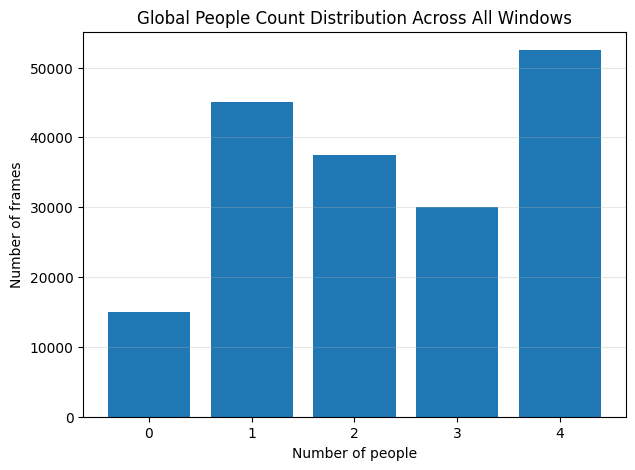

In [181]:
# Sum the number of frames for each fixed people count.
global_frame_counts = (
    window_df
    .groupby("people_count")["total_frames"]
    .sum()
    .reindex(range(MAX_PEOPLE + 1), fill_value=0)
)

for people_count, number_of_frames in global_frame_counts.items():
    print(f"Frames with {people_count} people: {number_of_frames}")

# Plot the global people-count distribution
people_count_values = np.arange(MAX_PEOPLE + 1)

plt.figure(figsize=(7, 5))
plt.bar(people_count_values, global_frame_counts)
plt.xlabel("Number of people")
plt.ylabel("Number of frames")
plt.title("Global People Count Distribution Across All Windows")
plt.xticks(people_count_values)
plt.grid(axis="y", alpha=0.3)
plt.show()

**People Count Conclusions**

- Recording windows are consistent in length: **7,500 frames** each.
- The people count is stable within each window, so splitting should be done by window.
- People-count classes are **imbalanced**; train/validation/test splits should preserve this distribution.

## Spatial Position Analysis

This section studies where people are located in the room and how close they are to each other within the same frame.

These checks are useful because localization difficulty is not only determined by the number of people. It also depends on whether people are concentrated in specific room areas and whether multiple people often appear close together.

In [182]:
def summarize_distances(distance_df, group_col="people_count"):
    summary_df = distance_df.groupby(group_col)["distance_m"].describe().reset_index()
    return summary_df.rename(columns={"50%": "median"})


position_rows, pair_distance_rows = [], []

for npz_path in npz_files:
    window_name = os.path.basename(npz_path)
    with np.load(npz_path) as data:
        people_xy = data["people_xy"].astype(np.float32)
        people_mask = data["people_mask"] > 0.5

    for frame_idx, (frame_xy, frame_mask) in enumerate(zip(people_xy, people_mask)):
        active_xy = frame_xy[frame_mask]
        people_count = len(active_xy)
        frame_info = {
            "window": window_name,
            "frame": frame_idx,
            "people_count": people_count,
        }

        position_rows.extend(
            {**frame_info, "slot": slot, "x": float(x), "y": float(y)}
            for slot, (x, y) in enumerate(active_xy)
        )

        pair_distance_rows.extend(
            {
                **frame_info,
                "person_a": person_a,
                "person_b": person_b,
                "distance_m": float(np.linalg.norm(active_xy[person_a] - active_xy[person_b])),
            }
            for person_a, person_b in combinations(range(people_count), 2)
        )

position_df = pd.DataFrame(position_rows)
pair_distance_df = pd.DataFrame(pair_distance_rows)

print("Active person positions:", len(position_df))
print("Same-frame person pairs:", len(pair_distance_df))

print("\n===== Position Summary =====")
display(position_df[["x", "y"]].describe())

if not pair_distance_df.empty:
    print("\n===== Pairwise Distance by People Count =====")
    display(summarize_distances(pair_distance_df))
else:
    print("No frames with at least two active people were found.")


Active person positions: 420000
Same-frame person pairs: 442500

===== Position Summary =====


,x,y
count,420000.000000,420000.000000
mean,2.234446,3.743039
std,1.042653,1.602250
min,-0.868638,-0.408482
25%,1.303625,2.450731
50%,2.237577,3.807454
75%,3.141699,4.954472
max,4.356274,7.855106



===== Pairwise Distance by People Count =====


,people_count,count,mean,std,min,25%,median,75%,max
0,2,37500.0,2.750360,1.119098,0.732140,1.884281,2.502137,3.403623,6.731599
1,3,90000.0,2.595429,1.085364,0.484404,1.805468,2.458826,3.166135,7.212054
2,4,315000.0,2.698513,1.089883,0.183676,1.935767,2.574441,3.342998,7.633662


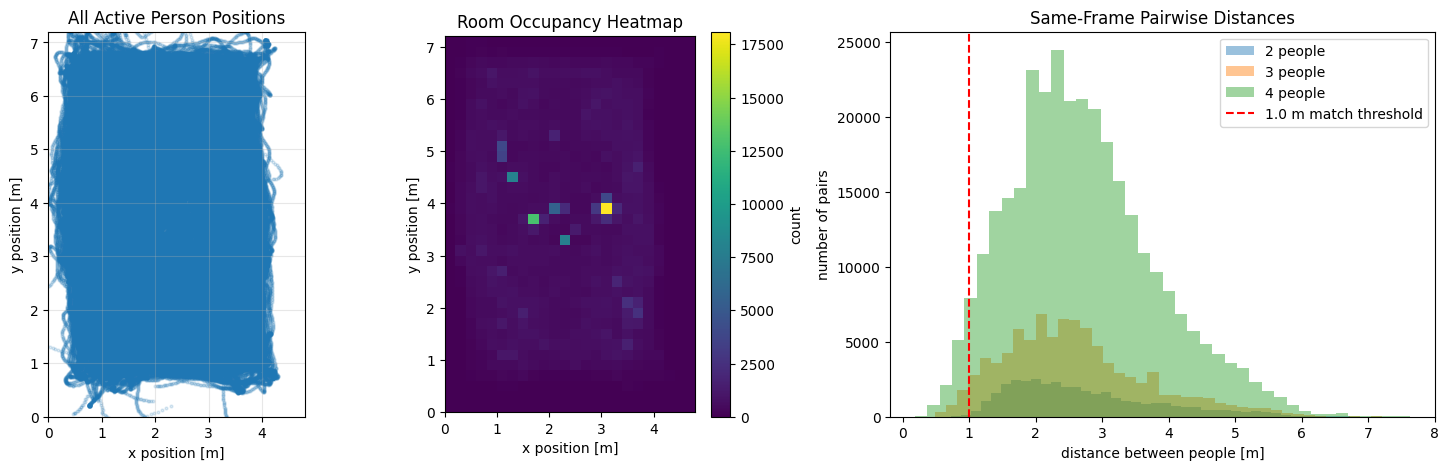

In [183]:
def format_room_axis(ax, title):
    ax.set_xlim(0, ROOM_X)
    ax.set_ylim(0, ROOM_Y)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x position [m]")
    ax.set_ylabel("y position [m]")
    ax.set_title(title)


fig, axes = plt.subplots(1, 3, figsize=(18, 5),     gridspec_kw={"width_ratios": [1, 1.15, 2], "wspace": 0.35})

# Spatial scatter: where people appear in the room.
axes[0].scatter(
    position_df["x"],
    position_df["y"],
    s=4,
    alpha=0.15,
)
format_room_axis(axes[0], "All Active Person Positions")
axes[0].grid(True, alpha=0.3)

# 2D occupancy heatmap: denser areas mean people appear there more often.
h = axes[1].hist2d(
    position_df["x"],
    position_df["y"],
    bins=[24, 36],
    range=[[0, ROOM_X], [0, ROOM_Y]],
    cmap="viridis",
)
format_room_axis(axes[1], "Room Occupancy Heatmap")
fig.colorbar(h[3], ax=axes[1], label="count")

# Distance distribution: close people are usually harder to separate.
if not pair_distance_df.empty:
    for people_count, group in pair_distance_df.groupby("people_count"):
        axes[2].hist(
            group["distance_m"],
            bins=40,
            alpha=0.45,
            label=f"{people_count} people",
        )
    axes[2].axvline(1.0, color="red", linestyle="--", label="1.0 m match threshold")
    axes[2].set_xlabel("distance between people [m]")
    axes[2].set_ylabel("number of pairs")
    axes[2].set_title("Same-Frame Pairwise Distances")
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5, "No pairwise distances", ha="center", va="center")
    axes[2].set_axis_off()

plt.show()


**Spatial Analysis Conclusions**

- People positions cover most of the room, with some denser regions.
- Multi-person frames often contain close pairs, especially when more people are present.
- Close people are likely to be the hardest cases for localization and peak separation.
- Some people are out of the boundaries. Consider it as noise to remove or just clip the positions to the room dimensions


# Preprocessing


In [184]:
def build_complex_cir(radar_iq):
    """
    radar_iq: (T, 6, 3, 120, 2)
    return:   complex array (T, 6, 3, 120)
    """
    I = radar_iq[..., 0]
    Q = radar_iq[..., 1]
    z = I + 1j * Q
    return z.astype(np.complex64)


def apply_declutter(x, mode="mean", alpha=0.98):
    """Remove the static background from the radar signal."""
    if mode == "mean":
        return x - x.mean(axis=0, keepdims=True)

    if mode == "ema":
        if not 0 <= alpha <= 1:
            raise ValueError("alpha must be in the range [0, 1].")

        output = np.empty_like(x)
        background = x[0].copy()
        output[0] = 0

        for t in range(1, len(x)):
            background = alpha * background + (1 - alpha) * x[t]
            output[t] = x[t] - background

        return output

    raise ValueError(f"Unknown declutter mode: {mode}")



def local_temporal_variance(x, window=9):
    """Compute temporal variance using a centered sliding window."""
    if window <= 0 or window % 2 == 0:
        raise ValueError("window must be a positive odd integer.")

    pad = window // 2
    x_pad = np.pad(x, ((pad, pad), (0, 0), (0, 0)), mode="edge")
    windows = sliding_window_view(x_pad, window, axis=0)

    return windows.var(axis=-1, dtype=np.float32)


## Signal Diagnostics: Full Range and Model Crop

Before building the training dataset, inspect one radar and one antenna as a
range-time map. This diagnostic checks whether the chosen range crop keeps the
useful room reflections while removing bins that are unlikely to help the model.

The physical range conversion is **1 bin = 0.15 m**. The model now uses bins
`[BIN_START:BIN_END] = [5:60]`, corresponding to **55 bins** and the physical
range **[0.75 m, 9.00 m)**. The first bins are excluded because near-range
reflections can be dominated by the sensor installation. Bins after 60 are
excluded because 9 m already covers the 8.65 m room diagonal with a margin.

The comparison plots preserve the original metric range on the vertical axis:
cropping the bins does not shift the physical distances. The example below uses
radar 0 at position **(2.4 m, 0.0 m)**, as documented in the exercise notebook.
When selecting another radar, update its position before interpreting the
ground-truth distance overlay.


In [185]:
RADAR_POSITIONS_XY = {
    0: (2.4, 0.0),  # SR250_1: south wall
    1: (4.8, 1.8),  # SR250_2: east wall, lower
    2: (4.8, 5.4),  # SR250_3: east wall, upper
    3: (2.4, 7.2),  # SR250_4: north wall
    4: (0.0, 5.4),  # SR250_5: west wall, upper
    5: (0.0, 1.8),  # SR250_6: west wall, lower
}

def plot_signal_diagnostics(
    radar_iq,
    radar_idx=0,
    antenna_idx=0,
    people_xy=None,
    people_mask=None,
    radar_positions_xy=RADAR_POSITIONS_XY,
    bin_start=5,
    bin_end=58,
    bin_size_m=0.15,\
    frame_limit=1200,
    clip_percentile=99.5,
    declutter_mode="ema",
    ema_alpha=0.98,
):
    """Plot raw/decluttered CIR and the range crop used by the model."""
    # Select one radar antenna and apply the same complex decluttering used later.
    raw_signal = build_complex_cir(radar_iq[:, radar_idx, antenna_idx])
    decluttered_signal = apply_declutter(raw_signal, mode=declutter_mode, alpha=ema_alpha)

    # Keep the diagnostic plot small and convert bin indices to physical range.
    if frame_limit is None:
        frame_limit = len(raw_signal)
    n_frames = min(int(frame_limit), len(raw_signal))
    n_bins = raw_signal.shape[1]
    bin_start = max(0, int(bin_start))
    bin_end = n_bins if bin_end is None else min(int(bin_end), n_bins)
    if n_frames <= 0 or bin_start >= bin_end:
        raise ValueError("frame_limit and bin crop must select valid data.")

    frame_axis = np.arange(n_frames)
    frame_extent = [0, max(n_frames - 1, 1)]
    full_range = np.array([0, n_bins], dtype=np.float32) * bin_size_m
    crop_range = np.array([bin_start, bin_end], dtype=np.float32) * bin_size_m

    raw_mag = np.abs(raw_signal[:n_frames])
    decluttered_mag = np.abs(decluttered_signal[:n_frames])
    raw_clip, decluttered_clip = [float(np.percentile(x, clip_percentile)) for x in (raw_mag, decluttered_mag)]

    print(f"Diagnostics: radar={radar_idx}, antenna={antenna_idx}, frames={n_frames}, clipping percentile={clip_percentile}")
    print(f"Raw magnitude clip max        : {raw_clip:.3f}")
    print(f"Decluttered magnitude clip max: {decluttered_clip:.3f}")
    print(f"Model crop: bins [{bin_start}:{bin_end}] -> {bin_end - bin_start} bins, range [{crop_range[0]:.2f}, {crop_range[1]:.2f}) m")

    def heatmap(ax, data, title, range_extent, vmax, ylabel="Range [m]"):
        image = ax.imshow(data.T, aspect="auto", origin="lower", extent=frame_extent + range_extent.tolist(), vmax=vmax)
        ax.set(title=title, xlabel="Frame", ylabel=ylabel)
        return image

    # First view: raw magnitude versus decluttered magnitude.
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    images = [
        heatmap(axes[0], raw_mag, f"Raw CIR magnitude - radar {radar_idx}, antenna {antenna_idx}", full_range, raw_clip),
        heatmap(axes[1], decluttered_mag, f"Decluttered CIR magnitude - EMA alpha={ema_alpha}", full_range, decluttered_clip, ""),
    ]
    for ax, image in zip(axes, images):
        ax.set_ylim(full_range)
        fig.colorbar(image, ax=ax, label="Magnitude")
    plt.tight_layout()
    plt.show()

    people_distance_m = None
    radar_position_xy = radar_positions_xy.get(radar_idx)
    has_people = people_xy is not None and people_mask is not None and radar_position_xy is not None
    if has_people:
        # Convert ground-truth positions to distance from the selected radar.
        active_people = people_mask >= 0.5
        people_distance_m = np.full(people_mask.shape, np.nan, dtype=np.float32)
        people_distance_m[active_people] = np.linalg.norm(
            people_xy[active_people] - np.asarray(radar_position_xy, dtype=np.float32), axis=1
        )

        # Second view: full range versus the model crop, with person distances overlaid.
        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        images = [
            heatmap(axes[0], decluttered_mag, "Before crop: full decluttered range", full_range, decluttered_clip, "Physical range [m]"),
            heatmap(axes[1], decluttered_mag[:, bin_start:bin_end], f"After crop: model bins [{bin_start}:{bin_end}]", crop_range, decluttered_clip, "Physical range [m]"),
        ]
        for start, end, label in [(full_range[0], crop_range[0], f"Ignored bins [0:{bin_start}]"), (crop_range[1], full_range[1], f"Ignored bins [{bin_end}:{n_bins}]")]:
            if start < end:
                axes[0].axhspan(start, end, alpha=0.15, color="red", label=label)

        for person_idx in range(people_mask.shape[1]):
            active = active_people[:n_frames, person_idx]
            if np.any(active):
                distance = people_distance_m[:n_frames, person_idx][active]
                for ax in axes:
                    ax.plot(frame_axis[active], distance, linewidth=1.5, label=f"Person slot {person_idx}")

        axes[0].set_ylim(full_range)
        axes[1].set_ylim(crop_range)
        for ax, image in zip(axes, images):
            ax.legend(loc="upper right")
            fig.colorbar(image, ax=ax, label="Decluttered magnitude")
        plt.tight_layout()
        plt.show()

Diagnostics: radar=0, antenna=0, frames=1200, clipping percentile=99.5
Raw magnitude clip max        : 21422.754
Decluttered magnitude clip max: 239.688
Model crop: bins [5:60] -> 55 bins, range [0.75, 9.00) m


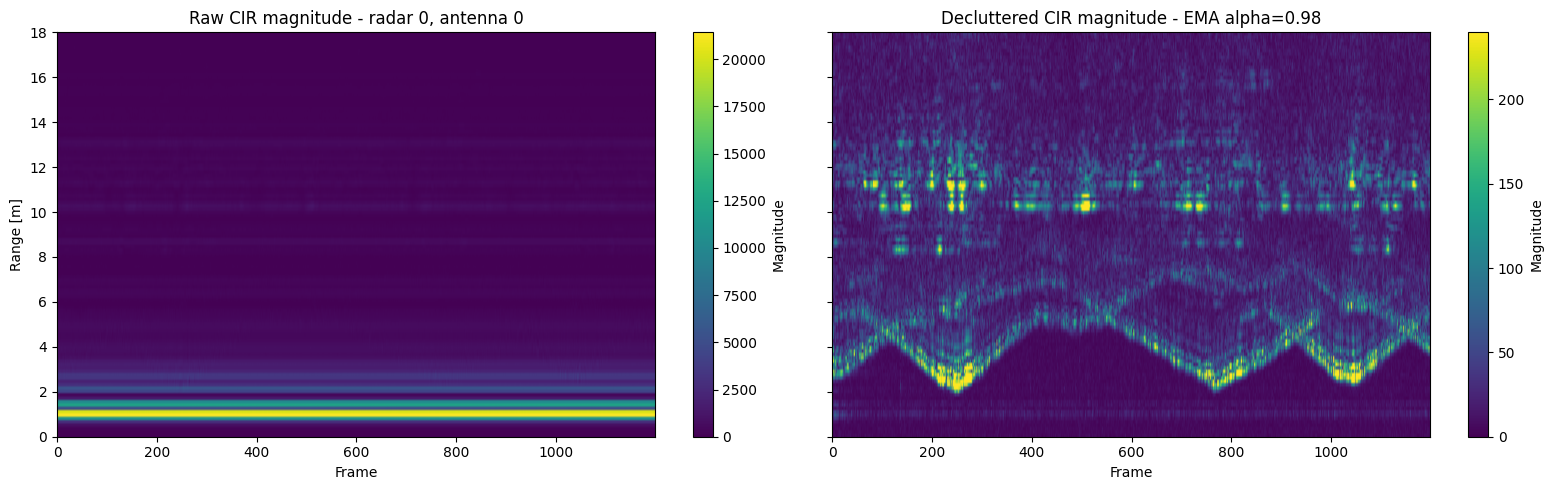

C:\Users\giuli\AppData\Local\Temp\ipykernel_16132\1303072213.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


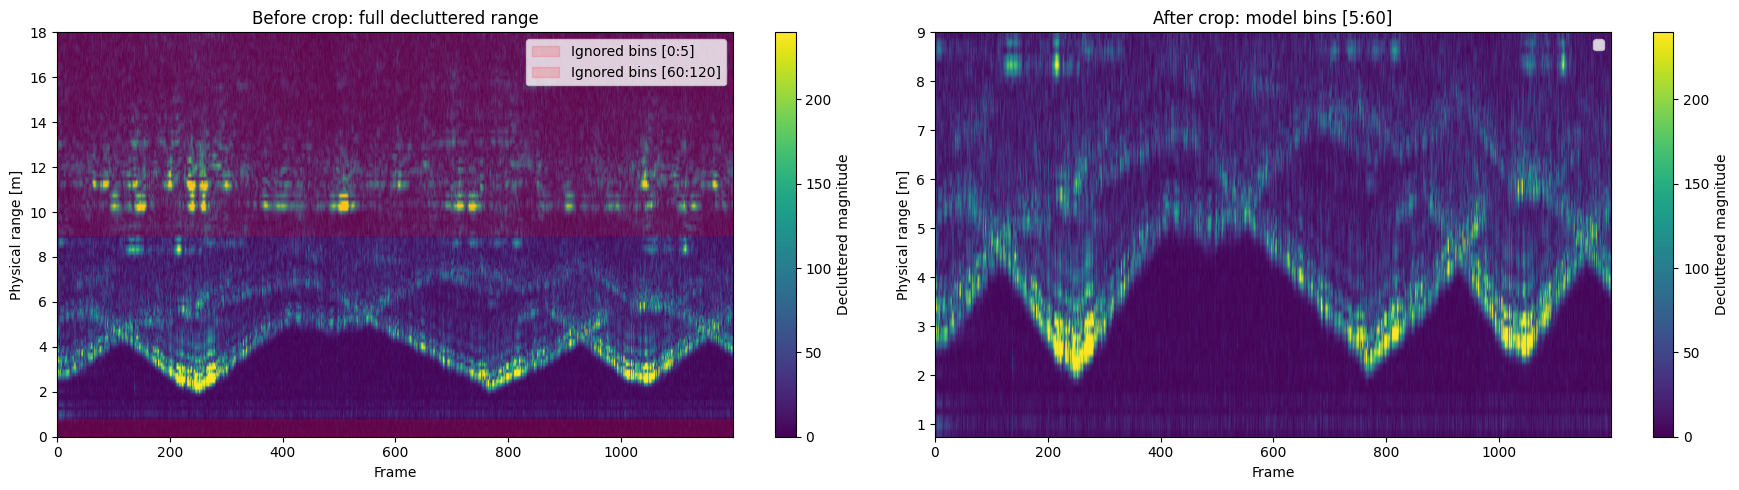

In [203]:
BIN_START = 5
BIN_END = 60
DECLUTTER_MODE = 'ema'
EMA_ALPHA = 0.98

# radar_idx selects both the radar signal and its room position.
plot_signal_diagnostics(
    radar,
    radar_idx=0,
    antenna_idx=0,
    people_xy=people_xy,
    people_mask=people_mask,
    bin_start=BIN_START,
    bin_end=BIN_END,
    declutter_mode=DECLUTTER_MODE,
    ema_alpha=EMA_ALPHA,
)

### Radar Feature Extraction

The `build_radar_features()` function converts the raw radar data into a set of features that can be used as input for the model.

The original radar signal contains the **I** and **Q** components for each frame, sensor, channel, and range bin. Each radar has 3 RX antennas, so the pipeline first merges the sensor and antenna axes and then keeps the selected sensor-antenna channels. The function first combines I/Q into a complex signal:

$z = I + j*Q$

Static reflections from walls and furniture are removed while the signal is still complex. Magnitude is computed only after this background subtraction:

$z_{dc} = z - background(z)$

$magnitude_{dc} = |z_{dc}|$

This preserves phase information during decluttering. Subtracting the background after computing magnitude would discard that information too early.

The available feature blocks are:

- **Magnitude**: measures the intensity of the original reflected radar signal.
- **Complex-decluttered magnitude**: measures the residual intensity after complex background subtraction.
- **Motion magnitude**: measures how much the complex-decluttered magnitude changes between consecutive frames.
- **Local temporal variance**: measures how much the original magnitude varies within a short time window.
- **Phase difference**: measures the change in signal phase between consecutive frames and can capture small movements.

Only the features enabled in the configuration are included. The function also selects the desired radar channels and range bins. With `BIN_START = 5` and `BIN_END = 60`, the model keeps 55 bins corresponding to the physical range `[0.75 m, 9.00 m)`.

The final output has shape:

(number of frames, selected range bins, feature channels)

With the current configuration, the model uses complex-decluttered magnitude, motion magnitude, local temporal variance, and phase difference.


In [187]:
def build_radar_features(
    radar_iq,
    selected_channels,
    use_log=True,
    declutter_mode="mean",
    ema_alpha=0.98,
    use_mag=False,
    use_decluttered_mag=False,
    use_motion_mag=True,
    use_local_variance=True,
    variance_window=9,
    use_phase_diff=False,
    bin_start=0,
    bin_end=None,
):
    """
    Convert raw IQ radar data into model features.

    Input:
      radar_iq: (T, sensors, channels, bins, 2)

    Output:
      features: (T, selected_bins, feature_channels)
    """
    number_of_frames = radar_iq.shape[0]
    number_of_bins = radar_iq.shape[3]

    # Merge sensors and channels, then keep only the useful channels.
    radar_iq = radar_iq.transpose(0, 3, 1, 2, 4)
    radar_iq = radar_iq.reshape(number_of_frames, number_of_bins, -1, 2)
    radar_iq = radar_iq[:, :, selected_channels]

    complex_cir = build_complex_cir(radar_iq)
    magnitude = np.abs(complex_cir).astype(np.float32)

    if use_log:
        magnitude = np.log1p(magnitude)

    feature_blocks = []

    if use_mag:
        feature_blocks.append(magnitude)

    if use_decluttered_mag or use_motion_mag:
        # Remove static reflections before magnitude so phase information is
        # still available while estimating the complex background.
        decluttered_complex_cir = apply_declutter(
            complex_cir,
            declutter_mode,
            ema_alpha,
        )
        decluttered_magnitude = np.abs(decluttered_complex_cir).astype(np.float32)

        if use_log:
            decluttered_magnitude = np.log1p(decluttered_magnitude)

    if use_decluttered_mag:
        feature_blocks.append(decluttered_magnitude)

    if use_motion_mag:
        motion_magnitude = np.abs(
            np.diff(
                decluttered_magnitude,
                axis=0,
                prepend=decluttered_magnitude[:1],
            )
        )
        feature_blocks.append(motion_magnitude)

    if use_local_variance:
        temporal_variance = local_temporal_variance(
            magnitude,
            window=variance_window,
        )
        feature_blocks.append(temporal_variance)

    if use_phase_diff:
        phase_difference = np.zeros_like(magnitude)

        phase_difference[1:] = np.angle(
            complex_cir[1:] * np.conj(complex_cir[:-1])
        )

        feature_blocks.append(phase_difference)

    if not feature_blocks:
        raise ValueError("Enable at least one feature block.")

    features = np.concatenate(feature_blocks, axis=2)

    return features[:, bin_start:bin_end, :].astype(np.float32)


In [188]:
features = build_radar_features(
    radar.astype(np.float32),
    selected_channels=SELECTED_CHANNELS,
    use_log=USE_LOG,
    declutter_mode=DECLUTTER_MODE,
    ema_alpha=EMA_ALPHA,
    use_mag=USE_MAG,
    use_decluttered_mag=USE_DECLUTTERED_MAG,
    use_motion_mag=USE_MOTION_MAG,
    use_phase_diff=USE_PHASE_DIFF,
    use_local_variance=USE_LOCAL_VARIANCE,
    variance_window=VARIANCE_WINDOW,
    bin_start=BIN_START,
    bin_end=BIN_END,
)

print('Feature tensor shape:', features.shape)


Feature tensor shape: (7500, 55, 24)


# Dataset Preparation


In [189]:
def sort_people_by_x(positions, mask):
    """Sort valid people from left to right and pad empty slots with zeros."""
    valid_positions = positions[mask.astype(bool)]
    valid_positions = valid_positions[np.argsort(valid_positions[:, 0])]

    number_of_people = min(len(valid_positions), MAX_PEOPLE)

    sorted_positions = np.zeros((MAX_PEOPLE, 2), dtype=np.float32)
    sorted_mask = np.zeros(MAX_PEOPLE, dtype=np.float32)

    sorted_positions[:number_of_people] = valid_positions[:number_of_people]
    sorted_mask[:number_of_people] = 1.0

    return sorted_positions, sorted_mask

In [190]:
def build_samples_from_window(npz_path, seq_len=12, frame_stride=8):
    """
    Convert one NPZ recording window into model samples.

    Each input sample contains a sequence of consecutive radar frames.
    The target positions are taken from the last frame of the sequence.

    Returns:
      X_sequences : (N, seq_len, B_used, C_feat)
      y_positions : (N, MAX_PEOPLE, 2) --> (N, 4, 2)
      y_masks     : (N, MAX_PEOPLE)--> (N, 4)
      end_frames  : (N,)
    """
    with np.load(npz_path) as data:
        radar = data["radar_cir_iq"].astype(np.float32, copy=False)
        people_positions = data["people_xy"].astype(np.float32, copy=False)
        people_masks = data["people_mask"].astype(np.float32, copy=False)

    # Extract radar features for every frame in the window.
    features = build_radar_features(
        radar,
        selected_channels=SELECTED_CHANNELS,
        use_log=USE_LOG,
        declutter_mode=DECLUTTER_MODE,
        ema_alpha=EMA_ALPHA,
        use_mag=USE_MAG,
        use_decluttered_mag=USE_DECLUTTERED_MAG,
        use_motion_mag=USE_MOTION_MAG,
        use_local_variance=USE_LOCAL_VARIANCE,
        variance_window=VARIANCE_WINDOW,
        use_phase_diff=USE_PHASE_DIFF,
        bin_start=BIN_START,
        bin_end=BIN_END,
    )

    sequences = []
    position_labels = []
    mask_labels = []
    end_frames = []

    number_of_frames = features.shape[0]

    # Build sequences of consecutive frames.
    for end_frame in range(seq_len - 1, number_of_frames, frame_stride):
        start_frame = end_frame - seq_len + 1

        # Use the radar sequence as input.
        sequence = features[start_frame:end_frame + 1]

        # Use the people positions in the final frame as the target.
        positions, mask = sort_people_by_x(
            people_positions[end_frame],
            people_masks[end_frame],
        )

        sequences.append(sequence)
        position_labels.append(positions)
        mask_labels.append(mask)
        end_frames.append(end_frame)

    number_of_bins = features.shape[1]
    number_of_features = features.shape[2]

    # Return correctly shaped empty arrays if no valid sample was found.
    if not sequences:
        return (
            np.empty((0, seq_len, number_of_bins, number_of_features), dtype=np.float32),
            np.empty((0, MAX_PEOPLE, 2), dtype=np.float32),
            np.empty((0, MAX_PEOPLE), dtype=np.float32),
            np.empty((0,), dtype=np.int32),
        )

    return (
        np.stack(sequences).astype(np.float32),
        np.stack(position_labels).astype(np.float32),
        np.stack(mask_labels).astype(np.float32),
        np.array(end_frames, dtype=np.int32),
    )


## Train, Validation, and Test Split

Split entire recording windows before building samples. This prevents overlapping radar sequences from the same acquisition from leaking across splits.

The dataset contains only two empty-room windows. Keep one in training and one in the final test set; validation therefore covers the non-empty classes.


In [191]:
def summarize_split(files, split_name=""):
    """Print the number of windows for each people count."""
    labels = [
        people_count_by_window[os.path.basename(npz_path)]
        for npz_path in files
    ]

    histogram = (
        pd.Series(labels)
        .value_counts()
        .reindex(range(MAX_PEOPLE + 1), fill_value=0)
        .sort_index()
    )

    print(f"\n===== {split_name} Window Distribution =====")
    print("Total windows:", len(files))

    for people_count, number_of_windows in histogram.items():
        print(f"{people_count} people: {number_of_windows} windows")

    return histogram

In [192]:
from collections import defaultdict

# Associate each NPZ path with its fixed people count.
people_count_by_window = dict(
    zip(window_df["window"], window_df["people_count"])
)

# Reserve complete acquisition windows for validation and final testing.
# There are only two empty-room windows: one remains in train and one in test.
VALIDATION_WINDOWS_BY_PEOPLE_COUNT = {
    0: 0,
    1: 1,
    2: 1,
    3: 1,
    4: 1,
}
TEST_WINDOWS_BY_PEOPLE_COUNT = {
    0: 1,
    1: 1,
    2: 1,
    3: 1,
    4: 1,
}

windows_by_people_count = defaultdict(list)
for npz_path in npz_files:
    people_count = people_count_by_window[os.path.basename(npz_path)]
    windows_by_people_count[people_count].append(npz_path)

rng = np.random.default_rng(RANDOM_STATE)
for files in windows_by_people_count.values():
    files.sort()
    rng.shuffle(files)

train_files = []
validation_files = []
test_files = []

for people_count in range(MAX_PEOPLE + 1):
    files = windows_by_people_count[people_count]
    validation_count = VALIDATION_WINDOWS_BY_PEOPLE_COUNT[people_count]
    test_count = TEST_WINDOWS_BY_PEOPLE_COUNT[people_count]
    reserved_count = validation_count + test_count

    if reserved_count >= len(files):
        raise ValueError(
            f'{people_count} people: reserve at least one window for training. '
            f'Available={len(files)}, validation={validation_count}, test={test_count}.'
        )

    validation_files.extend(files[:validation_count])
    test_files.extend(files[validation_count:reserved_count])
    train_files.extend(files[reserved_count:])

train_files = sorted(train_files)
validation_files = sorted(validation_files)
test_files = sorted(test_files)

all_split_files = train_files + validation_files + test_files
if len(all_split_files) != len(npz_files) or len(set(all_split_files)) != len(npz_files):
    raise ValueError('Train, validation, and test splits must be disjoint and cover every window.')

train_window_hist = summarize_split(train_files, "Train")
validation_window_hist = summarize_split(validation_files, "Validation")
test_window_hist = summarize_split(test_files, "Test")



===== Train Window Distribution =====
Total windows: 15
0 people: 1 windows
1 people: 4 windows
2 people: 3 windows
3 people: 2 windows
4 people: 5 windows

===== Validation Window Distribution =====
Total windows: 4
0 people: 0 windows
1 people: 1 windows
2 people: 1 windows
3 people: 1 windows
4 people: 1 windows

===== Test Window Distribution =====
Total windows: 5
0 people: 1 windows
1 people: 1 windows
2 people: 1 windows
3 people: 1 windows
4 people: 1 windows


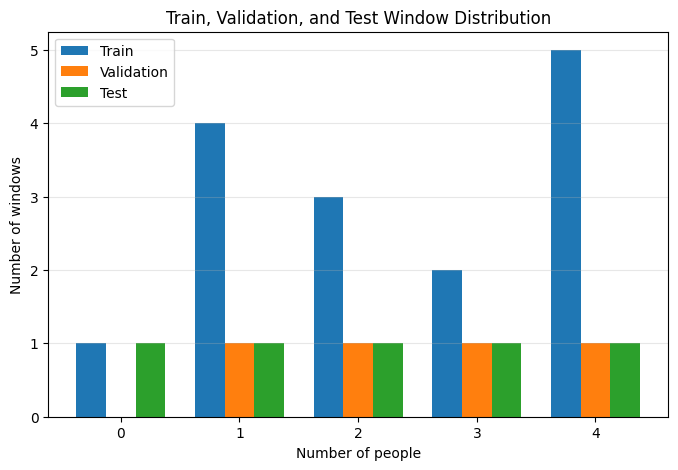

In [193]:
# Compare the people-count distribution across the three window-level splits.

people_counts = np.arange(MAX_PEOPLE + 1)

train_counts = [
    train_window_hist.get(count, 0)
    for count in people_counts
]
validation_counts = [
    validation_window_hist.get(count, 0)
    for count in people_counts
]
test_counts = [
    test_window_hist.get(count, 0)
    for count in people_counts
]

bar_width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(people_counts - bar_width, train_counts, width=bar_width, label="Train")
plt.bar(people_counts, validation_counts, width=bar_width, label="Validation")
plt.bar(people_counts + bar_width, test_counts, width=bar_width, label="Test")

plt.xlabel("Number of people")
plt.ylabel("Number of windows")
plt.title("Train, Validation, and Test Window Distribution")
plt.xticks(people_counts)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


## Build Dataset

The `build_dataset()` function combines the samples extracted from multiple NPZ recording windows.

For each file, it:
1. generates radar sequences and labels;
2. skips the file if it is too short to produce a sequence;
3. stores the source window name for every generated sample;
4. concatenates the results into a single dataset.

The same function is used to build the training, validation, and test sets.

In [194]:
def build_dataset(files):
    """Combine samples extracted from multiple NPZ recording windows."""
    radar_sequences_by_window = []
    position_labels_by_window = []
    mask_labels_by_window = []
    end_frame_indices_by_window = []
    sample_window_names = []

    for file_path in files:
        sequences, positions, masks, end_frame_indices = (
            build_samples_from_window(
                file_path,
                seq_len=SEQ_LEN,
                frame_stride=FRAME_STRIDE,
            )
        )

        number_of_samples = len(sequences)

        # A file cannot produce samples if it contains fewer than SEQ_LEN frames.
        if number_of_samples == 0:
            continue

        radar_sequences_by_window.append(sequences)
        position_labels_by_window.append(positions)
        mask_labels_by_window.append(masks)
        end_frame_indices_by_window.append(end_frame_indices)

        # Store the source file name for every generated sample.
        window_name = Path(file_path).name
        sample_window_names.extend([window_name] * number_of_samples)

    if not radar_sequences_by_window:
        raise ValueError("No valid samples were generated.")

    return (
        np.concatenate(radar_sequences_by_window, axis=0),
        np.concatenate(position_labels_by_window, axis=0),
        np.concatenate(mask_labels_by_window, axis=0),
        np.concatenate(end_frame_indices_by_window, axis=0),
        np.array(sample_window_names),
    )

In [195]:
X_train, y_coordinates_train, y_mask_train, train_frame_idx, train_window_name = (
    build_dataset(train_files)
)
print("X_train:", X_train.shape)
print("y_coordinates_train:", y_coordinates_train.shape)
print("y_mask_train:", y_mask_train.shape)

X_validation, y_coordinates_validation, y_mask_validation, validation_frame_idx, validation_window_name = (
    build_dataset(validation_files)
)
print("\nX_validation:", X_validation.shape)
print("y_coordinates_validation:", y_coordinates_validation.shape)
print("y_mask_validation:", y_mask_validation.shape)

X_test, y_coordinates_test, y_mask_test, test_frame_idx, test_window_name = (
    build_dataset(test_files)
)
print("\nX_test:", X_test.shape)
print("y_coordinates_test:", y_coordinates_test.shape)
print("y_mask_test:", y_mask_test.shape)


X_train: (7020, 16, 55, 24)
y_coordinates_train: (7020, 4, 2)
y_mask_train: (7020, 4)

X_validation: (1872, 16, 55, 24)
y_coordinates_validation: (1872, 4, 2)
y_mask_validation: (1872, 4)

X_test: (2340, 16, 55, 24)
y_coordinates_test: (2340, 4, 2)
y_mask_test: (2340, 4)


## Sanitize Active Coordinates

A small number of active ground-truth coordinates fall slightly outside the official room bounds. Clip only those active labels before validation and report how many values were corrected.


In [196]:
def sanitize_active_coordinates(split_name, y_coordinates, y_mask):
    """Clip active ground-truth coordinates to the official room bounds."""
    sanitized_coordinates = y_coordinates.copy()
    active = y_mask >= 0.5
    active_coordinates = sanitized_coordinates[active]

    if len(active_coordinates) == 0:
        print(f'{split_name}: no active coordinates to sanitize.')
        return sanitized_coordinates

    clipped_coordinates = np.clip(
        active_coordinates,
        [0.0, 0.0],
        [ROOM_X, ROOM_Y],
    )
    changed = np.any(active_coordinates != clipped_coordinates, axis=1)
    sanitized_coordinates[active] = clipped_coordinates

    print(
        f'{split_name}: clipped {int(changed.sum())} active coordinates to '
        f'[0, {ROOM_X}] x [0, {ROOM_Y}].'
    )
    return sanitized_coordinates


y_coordinates_train = sanitize_active_coordinates(
    'train', y_coordinates_train, y_mask_train
)
y_coordinates_validation = sanitize_active_coordinates(
    'validation', y_coordinates_validation, y_mask_validation
)
y_coordinates_test = sanitize_active_coordinates(
    'test', y_coordinates_test, y_mask_test
)


train: clipped 61 active coordinates to [0, 4.8] x [0, 7.2].
validation: clipped 0 active coordinates to [0, 4.8] x [0, 7.2].
test: clipped 5 active coordinates to [0, 4.8] x [0, 7.2].


In [197]:
def validate_dataset_split(split_name, X, y_coordinates, y_mask):
    """Validate generated samples before normalizing and saving them."""
    enabled_feature_blocks = sum((
        USE_MAG,
        USE_DECLUTTERED_MAG,
        USE_MOTION_MAG,
        USE_PHASE_DIFF,
        USE_LOCAL_VARIANCE,
    ))
    expected_input_shape = (
        SEQ_LEN,
        BIN_END - BIN_START,
        len(SELECTED_CHANNELS) * enabled_feature_blocks,
    )
    expected_coordinate_shape = (len(X), MAX_PEOPLE, 2)
    expected_mask_shape = (len(X), MAX_PEOPLE)

    if X.ndim != 4 or X.shape[1:] != expected_input_shape:
        raise ValueError(
            f'{split_name}: expected X shape (N, {expected_input_shape}), '
            f'got {X.shape}.'
        )
    if y_coordinates.shape != expected_coordinate_shape:
        raise ValueError(
            f'{split_name}: expected coordinate shape {expected_coordinate_shape}, '
            f'got {y_coordinates.shape}.'
        )
    if y_mask.shape != expected_mask_shape:
        raise ValueError(
            f'{split_name}: expected mask shape {expected_mask_shape}, '
            f'got {y_mask.shape}.'
        )
    if not np.isfinite(X).all():
        raise ValueError(f'{split_name}: radar features contain NaN or infinite values.')
    if not np.isfinite(y_coordinates).all() or not np.isfinite(y_mask).all():
        raise ValueError(f'{split_name}: labels contain NaN or infinite values.')
    if not np.all((y_mask == 0.0) | (y_mask == 1.0)):
        raise ValueError(f'{split_name}: masks must contain only 0 and 1.')

    active_coordinates = y_coordinates[y_mask >= 0.5]
    if len(active_coordinates) > 0:
        inside_room = (
            (active_coordinates[:, 0] >= 0.0)
            & (active_coordinates[:, 0] <= ROOM_X)
            & (active_coordinates[:, 1] >= 0.0)
            & (active_coordinates[:, 1] <= ROOM_Y)
        )
        if not np.all(inside_room):
            invalid_coordinates = active_coordinates[~inside_room]
            raise ValueError(
                f'{split_name}: active coordinates must lie inside '
                f'[0, {ROOM_X}] x [0, {ROOM_Y}]. '
                f'First invalid coordinate: {invalid_coordinates[0]}.'
            )


validate_dataset_split('train', X_train, y_coordinates_train, y_mask_train)
validate_dataset_split('validation', X_validation, y_coordinates_validation, y_mask_validation)
validate_dataset_split('test', X_test, y_coordinates_test, y_mask_test)
print("\nDataset validation passed.")


Dataset validation passed.


# Normalize Data


In [198]:
# Accumulate statistics in float64: the dataset is large enough for float32
# reductions to introduce visible numerical error.
mean = X_train.mean(axis=(0, 1, 2), dtype=np.float64, keepdims=True)
std = X_train.std(axis=(0, 1, 2), dtype=np.float64, keepdims=True)

# Keep stored statistics and normalized arrays compact.
mean = mean.astype(np.float32)
std = np.maximum(std, NORMALIZATION_EPS).astype(np.float32)

X_train -= mean
X_train /= std

X_validation -= mean
X_validation /= std

X_test -= mean
X_test /= std

print("Normalization done.")

# Check normalization using accurate reductions as well.
print("\nNormalized train mean by feature:")
print(X_train.mean(axis=(0, 1, 2), dtype=np.float64))

print("\nNormalized train std by feature:")
print(X_train.std(axis=(0, 1, 2), dtype=np.float64))


Normalization done.

Normalized train mean by feature:
[-2.61096898e-08  5.44157528e-08 -8.98963336e-08 -2.53278439e-08
  1.00269879e-07 -1.68205997e-08  4.10318229e-08 -1.57118509e-08
  2.63191688e-08  3.91556463e-08 -4.75127651e-08 -9.51428955e-10
  8.15049849e-10 -1.03470632e-08  9.24108212e-09 -6.79137842e-09
 -1.51210339e-09 -8.30633655e-09  4.41736954e-09 -4.84989281e-09
  3.02967668e-09 -1.17509096e-09  5.59888172e-09 -2.46896280e-09]

Normalized train std by feature:
[1.00000001 1.00000002 0.99999998 0.99999996 1.00000001 0.99999995
 1.00000001 1.00000003 1.         0.99999994 1.00000004 0.99999999
 1.00000002 0.99999998 0.99999998 1.00000002 0.99999996 0.99999997
 1.         0.99999998 0.99999996 0.99999996 0.99999996 0.99999999]


In [199]:
print("Train sample example:")
print("window:", train_window_name[0])
print("frame :", train_frame_idx[0])
print("input shape:", X_train[0].shape)
print("people coordinates:\n", y_coordinates_train[0])
print("mask label:", y_mask_train[0])

Train sample example:
window: window_000000.npz
frame : 15
input shape: (16, 55, 24)
people coordinates:
 [[0.94956553 4.0051503 ]
 [3.027298   2.2034955 ]
 [0.         0.        ]
 [0.         0.        ]]
mask label: [1. 1. 0. 0.]


# Save Processed Data


In [200]:
np.save(PROCESSED_DIR / 'X_train.npy', X_train)
np.save(PROCESSED_DIR / 'y_coordinates_train.npy', y_coordinates_train)
np.save(PROCESSED_DIR / 'y_mask_train.npy', y_mask_train)

np.save(PROCESSED_DIR / 'X_validation.npy', X_validation)
np.save(PROCESSED_DIR / 'y_coordinates_validation.npy', y_coordinates_validation)
np.save(PROCESSED_DIR / 'y_mask_validation.npy', y_mask_validation)

np.save(PROCESSED_DIR / 'X_test.npy', X_test)
np.save(PROCESSED_DIR / 'y_coordinates_test.npy', y_coordinates_test)
np.save(PROCESSED_DIR / 'y_mask_test.npy', y_mask_test)

np.save(PROCESSED_DIR / 'train_frame_idx.npy', train_frame_idx)
np.save(PROCESSED_DIR / 'validation_frame_idx.npy', validation_frame_idx)
np.save(PROCESSED_DIR / 'test_frame_idx.npy', test_frame_idx)
np.save(PROCESSED_DIR / 'train_window_name.npy', train_window_name)
np.save(PROCESSED_DIR / 'validation_window_name.npy', validation_window_name)
np.save(PROCESSED_DIR / 'test_window_name.npy', test_window_name)
np.savez(PROCESSED_DIR / 'normalization_stats.npz', mean=mean, std=std)

preprocessing_config = {
    'seq_len': SEQ_LEN,
    'frame_stride': FRAME_STRIDE,
    'selected_channels': SELECTED_CHANNELS,
    'use_log': USE_LOG,
    'declutter_mode': DECLUTTER_MODE,
    'ema_alpha': EMA_ALPHA,
    'use_mag': USE_MAG,
    'use_decluttered_mag': USE_DECLUTTERED_MAG,
    'use_motion_mag': USE_MOTION_MAG,
    'use_phase_diff': USE_PHASE_DIFF,
    'use_local_variance': USE_LOCAL_VARIANCE,
    'variance_window': VARIANCE_WINDOW,
    'bin_start': BIN_START,
    'bin_end': BIN_END,
    'room_x': ROOM_X,
    'room_y': ROOM_Y,
    'max_people': MAX_PEOPLE,
    'normalization_eps': NORMALIZATION_EPS,
    'train_files': train_files,
    'validation_files': validation_files,
    'test_files': test_files,
}

with open(PROCESSED_DIR / 'preprocessing_config.json', 'w', encoding='utf-8') as f:
    json.dump(preprocessing_config, f, indent=2)

print('Saved processed data to:', PROCESSED_DIR)


Saved processed data to: \Multi-Person-Detection\data\processed
